In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.shape

(17966, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [9]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

## EDA

<Axes: xlabel='price', ylabel='Count'>

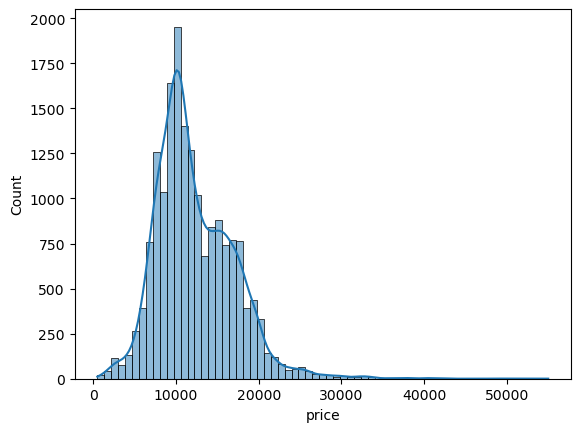

In [16]:
sns.histplot(df['price'],bins=65, kde = True)

In [18]:
df.corr(numeric_only =True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.636009,-0.707818,0.298506,-0.022967,-0.137311
price,0.636009,1.000000,-0.530659,0.406857,-0.346419,0.411178
mileage,-0.707818,-0.530659,1.000000,-0.260451,0.120075,0.215035
tax,0.298506,0.406857,-0.260451,1.000000,-0.502980,0.184363
mpg,-0.022967,-0.346419,0.120075,-0.502980,1.000000,-0.260521
engineSize,-0.137311,0.411178,0.215035,0.184363,-0.260521,1.000000


<Axes: >

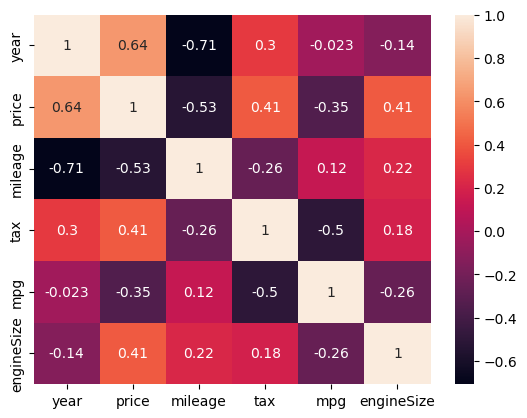

In [24]:
sns.heatmap(df.corr(numeric_only =True),annot= True)

<Axes: xlabel='mileage', ylabel='price'>

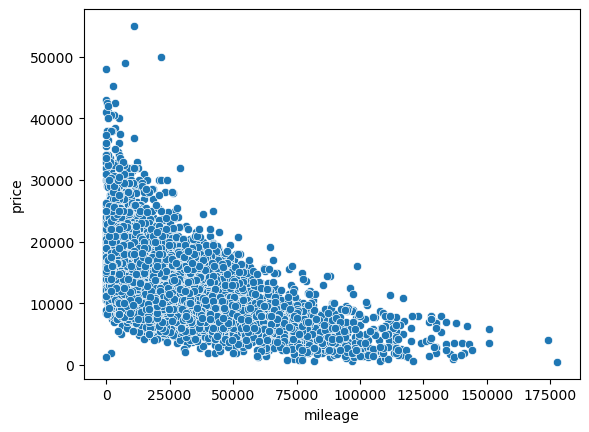

In [27]:
sns.scatterplot(data= df, x= 'mileage', y='price')

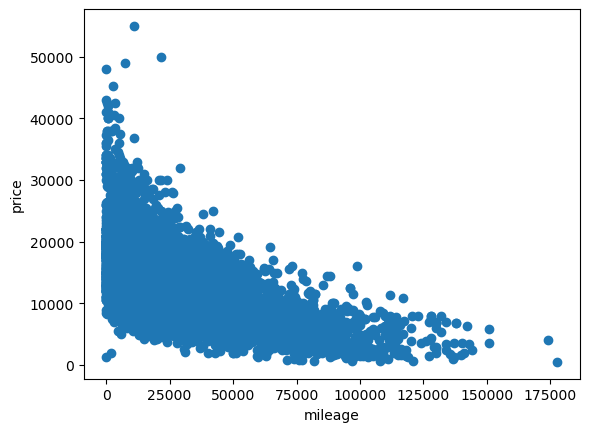

In [34]:
plt.scatter( df['mileage'], df['price'])
plt.xlabel('mileage')
plt.ylabel('price')
plt.show()

<Axes: xlabel='engineSize', ylabel='price'>

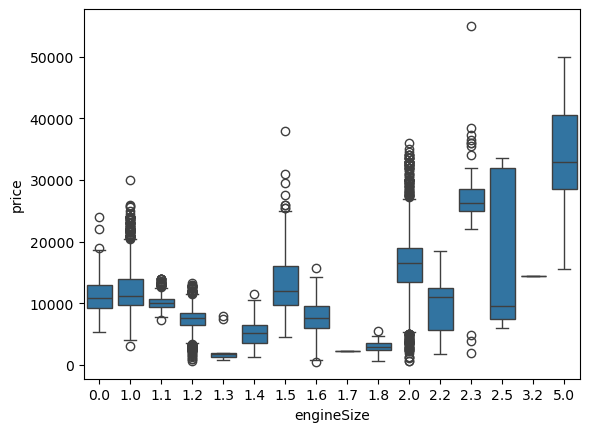

In [36]:
sns.boxplot(data = df ,x='engineSize', y= 'price')

<Axes: xlabel='engineSize', ylabel='price'>

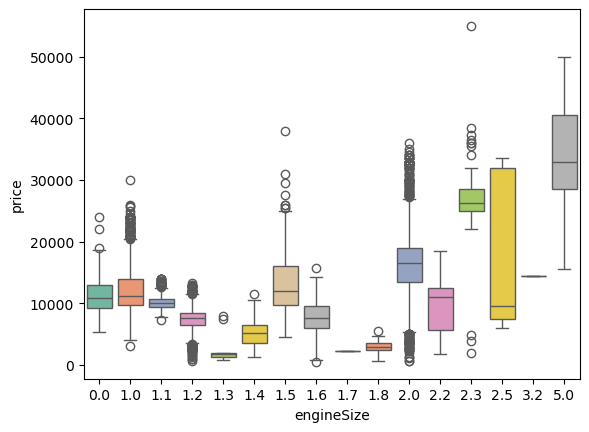

In [37]:
sns.boxplot(data = df ,x='engineSize', y= 'price',palette='Set2')

In [39]:
x= df.drop(columns='price', axis=1)
x

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [42]:
y= df['price']
y

,price
0,12000
1,14000
2,13000
3,17500
4,16500
...,...
17961,8999
17962,7499
17963,9999
17964,8299


## one hot encoding

In [49]:
x_encoded = pd.get_dummies(x, drop_first=True)

In [50]:
x_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,40700,30,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,7010,20,67.3,1.6,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,5007,145,57.7,1.2,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [51]:
x_encoded.astype(int)

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [53]:
x_encoded['tax'].value_counts()

tax
145    8944
0      2153
150    1944
125    1407
30     1236
20     1210
160     358
200     252
235     123
165     113
205      60
260      41
240      32
265      15
300      11
135      10
140       8
570       6
195       6
325       6
555       4
115       3
155       3
220       3
330       2
305       2
230       2
580       2
190       2
120       2
210       1
185       1
110       1
270       1
290       1
22        1
Name: count, dtype: int64

### we did scaling only numeric colums  (which columns are numeric in raw data, cause when we use one_hot_encoding it convert data into 0/1 . if we apply label encode then sclaing all columns

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns=['year','mileage','tax','mpg','engineSize']
x_encoded[columns] = scaler.fit_transform(x_encoded[columns])
x_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.067312,0.113779,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,-1.398088,0.890398,-1.343791,-0.020442,-0.811386,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,-0.910349,-0.839822,-1.505053,0.927668,0.576362,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,0.552866,-0.942690,0.510727,-0.020442,-0.348804,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


## create model for one hot encoding 

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [68]:
 X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.33, random_state=42)

In [70]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
y_pred= model.predict(X_test)
y_pred

array([[ 6676.74792864],
       [ 9175.10363172],
       [ 9876.15109278],
       ...,
       [19944.5783948 ],
       [ 5551.82314202],
       [10177.30406554]], shape=(5929, 1))

In [74]:
y_test

,price
17610,6995
7076,8999
1713,7998
1611,5491
16830,3790
...,...
6015,19000
10301,10940
15006,21999
5396,6995


In [76]:
r2= r2_score(y_test,y_pred)
r2

0.8402100144860558

## label encoding

In [64]:
from sklearn.preprocessing import LabelEncoder

x_label = x.copy()
le = LabelEncoder()

col = ['model', 'transmission', 'fuelType']

for c in col:
    x_label[c] = le.fit_transform(x_label[c])

In [65]:
x_label

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [66]:
from sklearn.preprocessing import StandardScaler

lab_scaler = StandardScaler()
co=['model','year','transmission','mileage','fuelType','tax','mpg','engineSize']
x_label[co] = scaler.fit_transform(x_label[co])
x_label

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


## model create for label encoding

In [78]:
 X_train, X_test, y_train, y_test = train_test_split(x_label, y, test_size=0.33, random_state=42)

In [79]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
y_pred= model.predict(X_test)
y_pred

array([[ 6157.52473246],
       [ 9286.53653694],
       [ 9519.82817502],
       ...,
       [19580.21385231],
       [ 7384.33202962],
       [ 9960.74790235]], shape=(5929, 1))

In [81]:
y_test

,price
17610,6995
7076,8999
1713,7998
1611,5491
16830,3790
...,...
6015,19000
10301,10940
15006,21999
5396,6995


In [82]:
r2= r2_score(y_test,y_pred)
r2

0.7310215557391141